# Preprocessing

Builds and saves the stratified train/val/test splits that all model notebooks load.

**Run this notebook exactly once.** After the CSV files exist in `data/`, you never need to run it again.

> **Important:** `clean_text` is only for the NBOW + Logistic Regression pipeline.
> DistilBERT notebooks use the raw `comment_text` column.

In [16]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.data_utils import load_and_label, make_splits, class_weight_dict
from src.preprocessing import clean_text, apply_cleaning, length_stats, clean_text_ablation

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print("Imports OK")


Imports OK


## 1. Load and label

In [18]:
RAW_PATH = '../data/train.csv'

df = load_and_label(RAW_PATH)
print(f"Loaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(f"Label distribution:\n{df['label'].value_counts().to_string()}")
df.head(3)


Loaded 159,571 rows
Columns: ['id', 'comment_text', 'label']
Label distribution:
label
0    143346
1     16225


,id,comment_text,label
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0


## 2. Create stratified splits

In [19]:
train, val, test = make_splits(df)

splits = {'Train': train, 'Val': val, 'Test': test}
for name, split in splits.items():
    n = len(split)
    pct = split['label'].mean()
    print(f"{name:6s}: {n:,} rows  |  toxic: {split['label'].sum():,} ({pct:.2%})")


Train : 127,656 rows  |  toxic: 12,980 (10.17%)
Val   : 15,957 rows  |  toxic: 1,622 (10.16%)
Test  : 15,958 rows  |  toxic: 1,623 (10.17%)


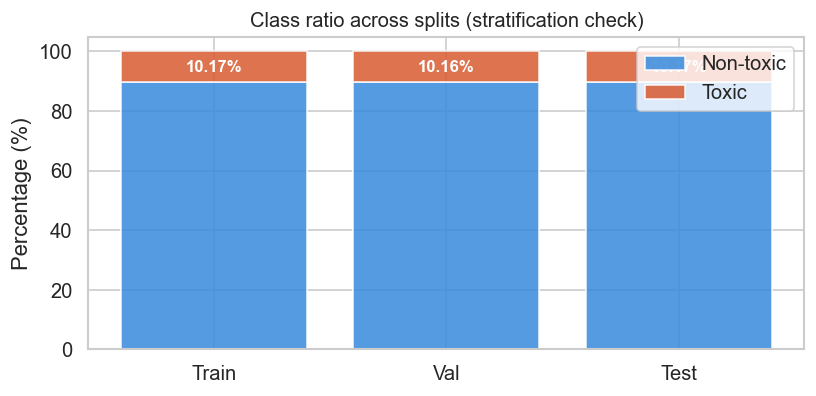

If all three toxic % values are nearly identical, stratification worked correctly.


In [20]:
# Visual confirmation: class ratio is consistent across splits
fig, ax = plt.subplots(figsize=(7, 3.5))

x = np.arange(3)
split_names = ['Train', 'Val', 'Test']
toxic_pcts    = [s['label'].mean() * 100 for s in [train, val, test]]
nontoxic_pcts = [100 - p for p in toxic_pcts]

bars1 = ax.bar(x, nontoxic_pcts, label='Non-toxic', color='#378ADD', alpha=0.85)
bars2 = ax.bar(x, toxic_pcts, bottom=nontoxic_pcts, label='Toxic', color='#D85A30', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(split_names)
ax.set_ylabel('Percentage (%)')
ax.set_title('Class ratio across splits (stratification check)', fontsize=12)
ax.legend(loc='upper right')

for bar, pct in zip(bars2, toxic_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
            f'{pct:.2f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/preprocessing_split_check.png', dpi=150, bbox_inches='tight')
plt.show()

print("If all three toxic % values are nearly identical, stratification worked correctly.")


## 3. Text cleaning

Applied only to the NBOW + LR pipeline. We keep the original `comment_text` alongside `clean_text` in the CSV so DistilBERT notebooks can use the raw column.

In [22]:
# Show the cleaning steps one by one on a hard example
example = "You're a complete F***ING moron!!! visit http://troll.com for more <b>IDIOTS</b>"
print(f"Original:   {example}")
print()

# Step by step
import re
step1 = example.lower()
print(f"1. Lower:   {step1}")

step2 = re.sub(r'<[^>]+>', ' ', step1)
print(f"2. No HTML: {step2}")

step3 = re.sub(r'http\S+|www\.\S+', ' ', step2)
print(f"3. No URLs: {step3}")

contractions = {r"won't":'will not', r"can't":'cannot', r"n't":' not',
                r"'re":' are', r"'s":' is', r"'d":' would',
                r"'ll":' will', r"'ve":' have', r"'m":' am'}
step4 = step3
for pat, rep in contractions.items():
    step4 = re.sub(pat, rep, step4)
print(f"4. Expand:  {step4}")

step5 = re.sub(r'[^\w\s]', ' ', step4)
print(f"5. No punc: {step5}")

step6 = re.sub(r'\s+', ' ', step5).strip()
print(f"6. Final:   {step6}")
print()
print(f"Result via clean_text(): {clean_text(example)}")


Original:   You're a complete F***ING moron!!! visit http://troll.com for more <b>IDIOTS</b>

1. Lower:   you're a complete f***ing moron!!! visit http://troll.com for more <b>idiots</b>
2. No HTML: you're a complete f***ing moron!!! visit http://troll.com for more  idiots 
3. No URLs: you're a complete f***ing moron!!! visit   for more  idiots 
4. Expand:  you are a complete f***ing moron!!! visit   for more  idiots 
5. No punc: you are a complete f   ing moron    visit   for more  idiots 
6. Final:   you are a complete f ing moron visit for more idiots

Result via clean_text(): you are a complete f ing moron visit for more idiots


In [23]:
# Apply to all splits — keep original text for DistilBERT
train_clean = apply_cleaning(train, keep_original=True)
val_clean   = apply_cleaning(val,   keep_original=True)
test_clean  = apply_cleaning(test,  keep_original=True)

train_clean = train_clean[train_clean["clean_text"].str.strip() != ""]
val_clean   = val_clean[val_clean["clean_text"].str.strip() != ""]
test_clean  = test_clean[test_clean["clean_text"].str.strip() != ""]

# Verify both columns present
print("Columns in cleaned train split:", list(train_clean.columns))
print()

# Before / after on 5 real examples
sample = train_clean.sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f"RAW:   {row['comment_text'][:120]}")
    print(f"CLEAN: {row['clean_text'][:120]}")
    print()


Columns in cleaned train split: ['id', 'comment_text', 'label', 'clean_text']

RAW:   That's a fault on the website, check the date. I did it a while ago. I remember when I first looked at it, it was very s
CLEAN: that is a fault on the website check the date i did it a while ago i remember when i first looked at it it was very simi

RAW:   I agree, Fuller is a useless stupid fuck
CLEAN: i agree fuller is a useless stupid fuck

RAW:   Biography - Peggy Kerry
CLEAN: biography peggy kerry

RAW:   Hi SarekOfVulcan,

I've been trying to focus on writing the article (tough to do when you get ignored and things get del
CLEAN: hi sarekofvulcan i have been trying to focus on writing the article tough to do when you get ignored and things get dele

RAW:   Re: Hebrew Wikipedia 

If the Hebrew Wikipedia has relevant external links, just use them in the article, instead of lin
CLEAN: re hebrew wikipedia if the hebrew wikipedia has relevant external links just use them in the article instead of lin

## 4. Cleaning ablation

Does each cleaning step actually help? We test this in a future notebook, but here we set up the ablation function and inspect what each step removes.

In [24]:
ablation_configs = {
    'baseline (all steps)':         dict(remove_html=True, remove_urls=True, expand_contractions=True, remove_punctuation=True),
    'no HTML removal':              dict(remove_html=False, remove_urls=True, expand_contractions=True, remove_punctuation=True),
    'no URL removal':               dict(remove_html=True, remove_urls=False, expand_contractions=True, remove_punctuation=True),
    'no contraction expansion':     dict(remove_html=True, remove_urls=True, expand_contractions=False, remove_punctuation=True),
    'no punctuation removal':       dict(remove_html=True, remove_urls=True, expand_contractions=True, remove_punctuation=False),
}

example2 = "I can't believe you won't read http://docs.com <i>this</i> amazing text!"
print(f"Input: {example2}\n")
for name, kwargs in ablation_configs.items():
    result = clean_text_ablation(example2, **kwargs)
    print(f"{name}:")
    print(f"  {result}")
    print()


Input: I can't believe you won't read http://docs.com <i>this</i> amazing text!

baseline (all steps):
  i cannot believe you will not read this amazing text

no HTML removal:
  i cannot believe you will not read <i>this< i> amazing text

no URL removal:
  i cannot believe you will not read http docs com this amazing text

no contraction expansion:
  i can t believe you won t read this amazing text

no punctuation removal:
  i cannot believe you will not read this amazing text!



## 5. Vocabulary size after cleaning

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

# How many unique tokens before vs after cleaning?
raw_vocab = CountVectorizer(max_features=None).fit(train['comment_text'].fillna(''))
clean_vocab = CountVectorizer(max_features=None).fit(train_clean['clean_text'].fillna(''))

print(f"Vocabulary size — raw text:    {len(raw_vocab.vocabulary_):,}")
print(f"Vocabulary size — clean text:  {len(clean_vocab.vocabulary_):,}")
print(f"Reduction: {1 - len(clean_vocab.vocabulary_)/len(raw_vocab.vocabulary_):.1%}")


Vocabulary size — raw text:    166,586
Vocabulary size — clean text:  158,418
Reduction: 4.9%


## 6. Class weights

Compute and display class weights for reference. Logistic Regression and DistilBERT will both use these values.

In [27]:
weights = class_weight_dict(train)
print("Class weights (to correct for 9:1 imbalance):")
for cls, w in weights.items():
    label_name = 'non-toxic' if cls == 0 else 'toxic'
    print(f"  Class {cls} ({label_name}): {w:.4f}")

print()
print("Interpretation: the toxic class is upweighted by ~{:.1f}x relative to non-toxic.".format(
    weights[1] / weights[0]))
print("This means a toxic example contributes ~{:.1f}x as much to the loss.".format(
    weights[1] / weights[0]))


Class weights (to correct for 9:1 imbalance):
  Class 0 (non-toxic): 0.5566
  Class 1 (toxic): 4.9174

Interpretation: the toxic class is upweighted by ~8.8x relative to non-toxic.
This means a toxic example contributes ~8.8x as much to the loss.


## 7. Save splits to disk

In [28]:
import os
os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

train_clean.to_csv('../data/train_split.csv', index=False)
val_clean.to_csv('../data/val_split.csv',     index=False)
test_clean.to_csv('../data/test_split.csv',   index=False)

print("Saved splits:")
for name, path in [('Train', '../data/train_split.csv'),
                   ('Val',   '../data/val_split.csv'),
                   ('Test',  '../data/test_split.csv')]:
    size_mb = os.path.getsize(path) / 1e6
    n = len(pd.read_csv(path))
    print(f"  {name:6s} → {path}  ({n:,} rows, {size_mb:.1f} MB)")


Saved splits:
  Train  → ../data/train_split.csv  (127,644 rows, 101.4 MB)
  Val    → ../data/val_split.csv  (15,955 rows, 12.7 MB)
  Test   → ../data/test_split.csv  (15,958 rows, 12.8 MB)


## 8. Final checklist

Before moving to model notebooks, confirm all of these:

In [29]:
checks = {}

# 1. Splits saved
for path in ['../data/train_split.csv', '../data/val_split.csv', '../data/test_split.csv']:
    checks[f'file exists: {os.path.basename(path)}'] = os.path.exists(path)

# 2. Consistent toxic rate across splits
train_r = pd.read_csv('../data/train_split.csv', keep_default_na=False)['label'].mean()
val_r   = pd.read_csv('../data/val_split.csv', keep_default_na=False)['label'].mean()
test_r  = pd.read_csv('../data/test_split.csv', keep_default_na=False)['label'].mean()
checks['toxic rate consistent (within 0.5%)'] = abs(train_r - val_r) < 0.005 and abs(train_r - test_r) < 0.005

# 3. Both columns present
cols = pd.read_csv('../data/train_split.csv').columns.tolist()
checks['comment_text column present'] = 'comment_text' in cols
checks['clean_text column present']   = 'clean_text' in cols
checks['label column present']        = 'label' in cols

# 4. No nulls in key columns
df_check = pd.read_csv('../data/train_split.csv')
checks['no nulls in comment_text'] = df_check['comment_text'].isnull().sum() == 0
checks['no nulls in clean_text']   = df_check['clean_text'].isnull().sum() == 0

print("Preprocessing checklist:")
all_pass = True
for check, passed in checks.items():
    icon = '✓' if passed else '✗'
    print(f"  {icon}  {check}")
    if not passed:
        all_pass = False

print()

if all_pass:
    print("All checks passed. Ready to proceed to model notebooks.")
else:
    print("Some checks failed — review the steps above before continuing.")


Preprocessing checklist:
  ✓  file exists: train_split.csv
  ✓  file exists: val_split.csv
  ✓  file exists: test_split.csv
  ✓  toxic rate consistent (within 0.5%)
  ✓  comment_text column present
  ✓  clean_text column present
  ✓  label column present
  ✓  no nulls in comment_text
  ✓  no nulls in clean_text

All checks passed. Ready to proceed to model notebooks.
